# Carlytics — Comprehensive BLIP VQA Visual Inspection Model

**Model:** `Salesforce/blip-vqa-base` (Visual Question Answering)

This notebook demonstrates **comprehensive 7-dimension visual car inspection** using pure local BLIP VQA:
1. **damage**: visible bodywork damage, dents, crash impacts, or scratches
2. **rust**: rust, corrosion, or paint peeling
3. **bumper**: front bumper, grille, and headlights condition
4. **windshield**: windshield and window glass condition
5. **wheels**: tires and wheels condition
6. **cleanliness**: exterior cleanliness & maintenance level
7. **paint_condition**: paint finish quality
8. **condition**: overall exterior bodywork rating (`Excellent`, `Good`, `Fair`, `Poor`)


In [10]:
# Install required packages (first run only)
# !pip install transformers torch torchvision Pillow requests


In [11]:
import io
import requests
import torch
from PIL import Image
from transformers import BlipForQuestionAnswering, BlipProcessor

print(f"PyTorch version     : {torch.__version__}")
import transformers
print(f"Transformers version: {transformers.__version__}")
print("Imports loaded successfully.")


PyTorch version     : 2.12.1+cpu
Transformers version: 5.13.0
Imports loaded successfully.


In [12]:
# ── Load BLIP VQA Model ───────────────────────────────────────────────────
MODEL_ID = "Salesforce/blip-vqa-base"
print(f"Loading {MODEL_ID} ...")

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForQuestionAnswering.from_pretrained(MODEL_ID)
model.eval()

print("BLIP VQA model loaded and ready.")


Loading Salesforce/blip-vqa-base ...


Loading weights: 100%|██████████| 788/788 [00:00<00:00, 7374.85it/s]


BLIP VQA model loaded and ready.


In [13]:
VQA_QUESTIONS = {
    "damage": "is there any dent, crash, scratch, or body damage on this car?",
    "rust": "is there any rust or paint damage on this car?",
    "bumper": "is the front bumper damaged or intact?",
    "windshield": "is the windshield or window glass cracked or broken?",
    "wheels": "are the tires or wheels damaged or clean?",
    "cleanliness": "is this car clean or dirty?",
    "paint_condition": "is the paint shiny, smooth, or scratched?",
    "condition_vqa": "is this car damaged or clean?",
}

def ask_vqa(image: Image.Image, question: str) -> str:
    # Run a single VQA pass on the image
    inputs = processor(image, question, return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=20)
    return processor.decode(output_ids[0], skip_special_tokens=True).strip().lower()


def inspect_car_visuals(image: Image.Image) -> dict:
    # Run comprehensive VQA inspection on a car image
    img_processed = image.convert("RGB").resize((384, 384), Image.LANCZOS)

    raw_vqa = {}
    for field, q in VQA_QUESTIONS.items():
        ans = ask_vqa(img_processed, q)
        raw_vqa[field] = ans

    has_damage = any(
        w in raw_vqa["damage"] for w in ["yes", "dent", "scratch", "damage", "crack", "bent", "crash", "wreck"]
    ) or ("damaged" in raw_vqa["bumper"]) or ("damaged" in raw_vqa["condition_vqa"])

    has_rust = any(w in raw_vqa["rust"] for w in ["yes", "rust", "corrosion", "peeling"])
    has_glass_damage = any(w in raw_vqa["windshield"] for w in ["yes", "crack", "cracked", "broken"])

    damage_text = "Visible bodywork damage, dent, or scratch detected on the vehicle." if has_damage else "No visible bodywork damage or dents detected."
    rust_text   = "Rust or paint corrosion visible on body panels." if has_rust else "No rust or paint corrosion visible."
    bumper_text = "Front bumper or headlights show signs of wear/damage." if "damaged" in raw_vqa["bumper"] else "Front bumper, grille, and headlights appear intact."
    glass_text  = "Windshield or window glass appears cracked/damaged." if has_glass_damage else "Windshield and window glass appear intact."
    wheels_text = "Tires and wheels show signs of wear/damage." if "damaged" in raw_vqa["wheels"] else "Wheels and tires appear in good condition."
    cleanliness_text = "Exterior appears dirty or dusty." if "dirty" in raw_vqa["cleanliness"] else "Exterior appears clean and well maintained."
    paint_text  = "Exterior paint finish appears smooth and intact." if any(w in raw_vqa["paint_condition"] for w in ["shiny", "smooth", "good", "clean"]) else "Exterior paint finish shows signs of surface wear."

    # Dynamically derive condition rating
    if has_damage and (has_rust or has_glass_damage):
        condition = "Poor"
    elif has_damage:
        is_severe = any(w in raw_vqa["damage"] for w in ["crash", "wreck", "bent", "yes"])
        condition = "Poor" if is_severe else "Fair"
    elif has_rust or has_glass_damage:
        condition = "Fair"
    else:
        condition = "Excellent" if "clean" in raw_vqa["condition_vqa"] or "new" in raw_vqa["bumper"] else "Good"

    summary = f"Overall condition: {condition}. {damage_text} {rust_text} {bumper_text} {glass_text} {cleanliness_text}"

    return {
        "damage": damage_text,
        "rust": rust_text,
        "bumper": bumper_text,
        "windshield": glass_text,
        "wheels": wheels_text,
        "cleanliness": cleanliness_text,
        "paint_condition": paint_text,
        "condition": condition,
        "summary": summary,
        "raw_vqa": raw_vqa,
    }

print("inspect_car_visuals() defined.")


inspect_car_visuals() defined.


In [14]:
def load_image_from_url(url: str) -> Image.Image:
    """Download an image from a URL."""
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=15)
    r.raise_for_status()
    return Image.open(io.BytesIO(r.content)).convert("RGB")


def load_image_from_file(file_path: str) -> Image.Image:
    """Load an image from a local file path."""
    return Image.open(file_path).convert("RGB")

print("Image loading helpers defined.")


Image loading helpers defined.


## Test: Load Car Image & Run Comprehensive Inspection

Image loaded: (640, 480) px


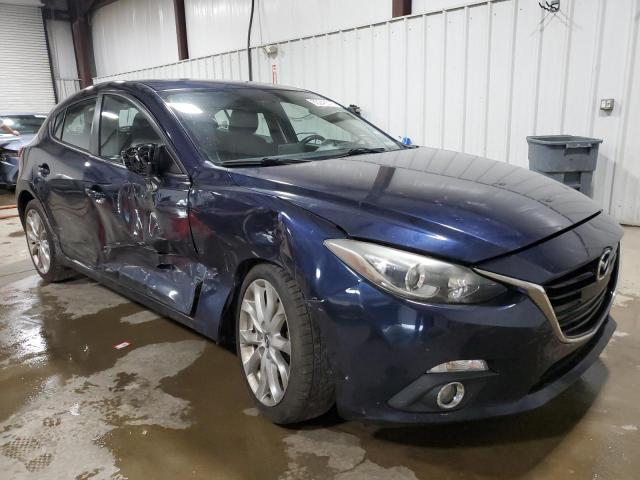

In [15]:
# ── Load Image ─────────────────────────────────────────────────────────────
# Test with your local car photo:
# LOCAL_PATH = r"C:\Users\PRANAV\Desktop\car.jpg"

IMAGE_URL = "https://cdn3.carsbidshistory.com/photo/60248515/JM1BM1L36F1265873_4.jpg"

try:
    img = load_image_from_url(IMAGE_URL)
    # img = load_image_from_file(LOCAL_PATH)
    print(f"Image loaded: {img.size} px")
    display(img)
except Exception as e:
    print(f"Could not load image: {e}")


In [16]:
# ── Run Visual Inspection ───────────────────────────────────────────────────
if 'img' in locals():
    report = inspect_car_visuals(img)
    print("=" * 65)
    print("COMPREHENSIVE STRUCTURED VISUAL REPORT:")
    print("=" * 65)
    print(f"  damage          : {report['damage']}")
    print(f"  rust            : {report['rust']}")
    print(f"  bumper          : {report['bumper']}")
    print(f"  windshield      : {report['windshield']}")
    print(f"  wheels          : {report['wheels']}")
    print(f"  cleanliness     : {report['cleanliness']}")
    print(f"  paint_condition : {report['paint_condition']}")
    print(f"  condition       : {report['condition']}")
    print(f"  SUMMARY: {report['summary']}")
    print("=" * 65)
    print(f"  RAW VQA ANSWERS: {report['raw_vqa']}")


COMPREHENSIVE STRUCTURED VISUAL REPORT:
  damage          : Visible bodywork damage, dent, or scratch detected on the vehicle.
  rust            : No rust or paint corrosion visible.
  bumper          : Front bumper or headlights show signs of wear/damage.
  windshield      : Windshield or window glass appears cracked/damaged.
  wheels          : Wheels and tires appear in good condition.
  cleanliness     : Exterior appears dirty or dusty.
  paint_condition : Exterior paint finish appears smooth and intact.
  condition       : Poor
  SUMMARY: Overall condition: Poor. Visible bodywork damage, dent, or scratch detected on the vehicle. No rust or paint corrosion visible. Front bumper or headlights show signs of wear/damage. Windshield or window glass appears cracked/damaged. Exterior appears dirty or dusty.
  RAW VQA ANSWERS: {'damage': 'yes', 'rust': 'no', 'bumper': 'damaged', 'windshield': 'broken', 'wheels': 'yes', 'cleanliness': 'dirty', 'paint_condition': 'smooth', 'condition_vqa': 

## Integration with Carlytics Pipeline

| Visual Field | Coverage | Source Model |
|--------------|----------|--------------|
| `damage` | Dents, scratches, bodywork damage | Pure local BLIP VQA |
| `rust` | Rust, corrosion, paint peeling | Pure local BLIP VQA |
| `bumper` | Front bumper, grille, headlights | Pure local BLIP VQA |
| `windshield` | Windshield & window glass condition | Pure local BLIP VQA |
| `wheels` | Tires & wheels condition | Pure local BLIP VQA |
| `cleanliness` | Exterior cleanliness & maintenance | Pure local BLIP VQA |
| `paint_condition` | Paint finish quality | Pure local BLIP VQA |
| `condition` | Overall physical bodywork rating | Pure local BLIP VQA |
